<a href="https://colab.research.google.com/github/IsagiTegaYoichi/Sentiment-Analysis-and-Topic-modelling-of-COVID-Vaccine-tweets2/blob/main/TOPIC_MODELLING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **READ DATA**

In [ ]:
#IMPORT LIBRARIES
import pandas as pd
print(pd.__version__)
df=pd.read_csv('Extracted.csv')
df = df.drop(columns=['Date Created', 'location'], axis=1)
df.head(12)

1.3.0


,Unnamed: 0,Tweet
0,0.0,@BygoneDiva @AusIndiMedia I think the Q here i...
1,1.0,@Asad_Umar can you please confirm &amp; do so...
2,2.0,This was me during my 2nd #Pfizer shot. https:...
3,3.0,Fuck Big Pharma. \nFollow the money.\nTrust no...
4,4.0,You know you’ve matured when you promise to do...
5,NaN,Tweet
6,0.0,#Moderna #seconddose got me hanging out in a r...
7,1.0,My anxiety is higher than normal because I had...
8,2.0,Okay I need a doctor or science person to expl...
9,3.0,📷 I am so grateful 🙏🏻 to have received my seco...


# **CLEANING DATA**

In [ ]:
#IMPORTING MODELS
!pip install tweet-preprocessor
import nltk; nltk.download('stopwords')
import re
import preprocessor as p
import numpy as np
import pandas as pd
from pprint import pprint
# NLTK Stop words
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['https', 'COVID', 're', 'covid', 'COVID19','co'])

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

# spacy for lemmatization
import spacy
# Plotting tools
!pip install pyLDAvis
import pyLDAvis
import matplotlib.pyplot as plt
%matplotlib inline



In [ ]:
# Convert to list

def preprocess_tweet(text):
    text = p.clean(text)
    return text
df['Tweet']=df['Tweet'].apply(preprocess_tweet)
df['Tweet'] = df['Tweet'].map(lambda x: x.lower())
df.head()
data = df.Tweet.values.tolist()
pprint(data[:1])

['i think the q here is not could these women have died from covid, making an']


In [ ]:
from gensim.utils import simple_preprocess
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))  # deacc=True removes punctuations

data_words = list(sent_to_words(data))

print(data_words[:1])

[['think', 'the', 'here', 'is', 'not', 'could', 'these', 'women', 'have', 'died', 'from', 'covid', 'making', 'an']]


In [ ]:
#BIGRAM AND TRIGRAM
# Build the bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)

# Faster way to get a sentence clubbed as a trigram/bigram
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# See trigram example
print(trigram_mod[bigram_mod[data_words[0]]])

/usr/local/lib/python3.7/dist-packages/gensim/models/phrases.py:598: UserWarning: For a faster implementation, use the gensim.models.phrases.Phraser class
  warnings.warn("For a faster implementation, use the gensim.models.phrases.Phraser class")


['think', 'the', 'here', 'is', 'not', 'could', 'these', 'women', 'have', 'died', 'from', 'covid', 'making', 'an']


In [ ]:
# Define functions for stopwords, bigrams, trigrams and lemmatization
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

In [ ]:
# Remove Stop Words
data_words_nostops = remove_stopwords(data_words)

# Form Bigrams
data_words_bigrams = make_bigrams(data_words_nostops)

# Initialize spacy 'en' model, keeping only tagger component (for efficiency)
# python3 -m spacy download en
nlp = spacy.load('en', disable=['parser', 'ner'])

# Do lemmatization keeping only noun, adj, vb, adv
data_lemmatized = lemmatization(data_words_bigrams, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])



In [ ]:
print(data_lemmatized[:1])

[['think', 'could', 'woman', 'die', 'make']]


# **LDA MODELLING**

In [ ]:
# Create Dictionary
id2word = corpora.Dictionary(data_lemmatized)

# Create Corpus
texts = data_lemmatized

# Term Document Frequency
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import models
corpus = [id2word.doc2bow(text) for text in texts]
TFIDF = models.TfidfModel(corpus) # Fit TF-IDF model
trans_TFIDF = TFIDF[corpus] # Apply TF-IDF model
# View
print(trans_TFIDF[:1])

In [ ]:
# Build LDA model
NUM_TOPICS=10
lda_model = gensim.models.LdaMulticore(corpus=trans_TFIDF,
                                       id2word=id2word,
                                       num_topics=NUM_TOPICS,
                                       random_state=100,
                                       chunksize=100,
                                       passes=10,
                                       per_word_topics=True)

In [ ]:
#View Topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.055*"sick" + 0.027*"try" + 0.019*"always" + 0.016*"ever" + 0.016*"ensure" '
  '+ 0.014*"ask" + 0.013*"spread" + 0.013*"really" + 0.013*"right" + '
  '0.012*"money"'),
 (1,
  '0.043*"lockdown" + 0.036*"never" + 0.026*"far" + 0.022*"today" + '
  '0.014*"health" + 0.013*"do" + 0.012*"check" + 0.011*"vaccinated" + '
  '0.011*"child" + 0.010*"hold"'),
 (2,
  '0.029*"say" + 0.026*"many" + 0.021*"take" + 0.020*"body" + 0.019*"come" + '
  '0.018*"door" + 0.018*"call" + 0.014*"kill" + 0.013*"die" + 0.013*"live"'),
 (3,
  '0.025*"available" + 0.023*"wait" + 0.021*"damage" + 0.019*"remember" + '
  '0.017*"month" + 0.015*"show" + 0.014*"scramble" + 0.013*"death" + '
  '0.013*"man" + 0.013*"vote"'),
 (4,
  '0.032*"less" + 0.023*"let" + 0.021*"virus" + 0.018*"new" + 0.016*"variant" '
  '+ 0.011*"sure" + 0.011*"people" + 0.010*"mean" + 0.010*"use" + '
  '0.009*"away"'),
 (5,
  '0.042*"thank" + 0.034*"go" + 0.018*"tell" + 0.017*"government" + '
  '0.013*"place" + 0.013*"s" + 0.012*"anti" + 0

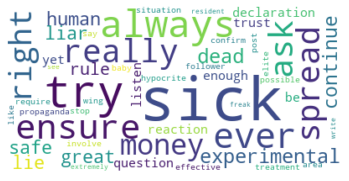

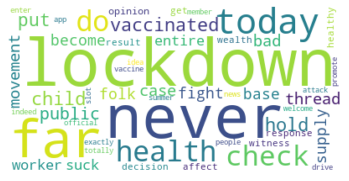

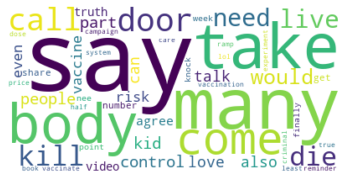

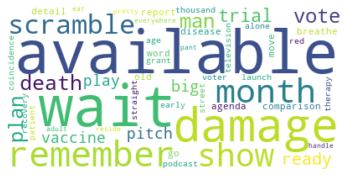

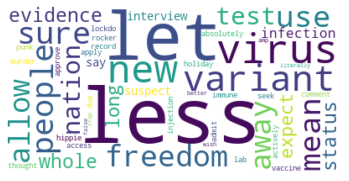

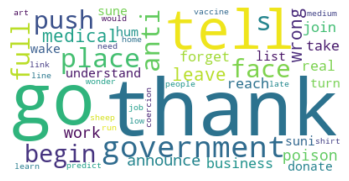

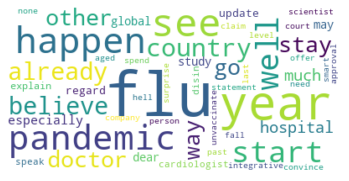

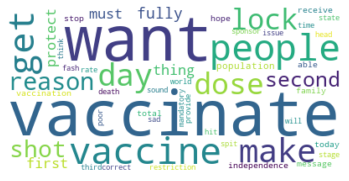

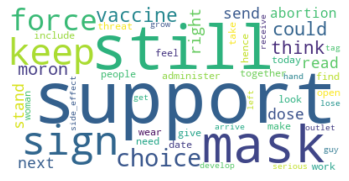

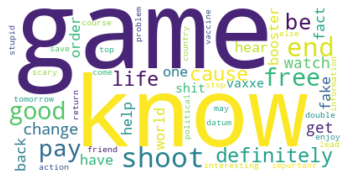

In [ ]:
from wordcloud import WordCloud
from mpl_toolkits import mplot3d
#Generate topic word clouds
topic = 0 # Initialize counter
while topic < NUM_TOPICS:
    topic_words_freq = dict(lda_model.show_topic(topic, topn=50))
    topic += 1
    # Generate Word Cloud for topic using frequencies
    wordcloud = WordCloud(background_color="white").generate_from_frequencies(topic_words_freq)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

In [ ]:
# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Coherence Score:  0.457086310159978


In [ ]:
def compute_coherence_values(corpus, dictionary, alpha, seed, texts, start, limit, step):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.LdaMulticore(corpus=corpus, id2word=dictionary, alpha=alpha, num_topics=num_topics, random_state=seed, passes=100)
        model_list.append(model)
        coherencemodel = gensim.models.CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values
model_list, coherence_values = compute_coherence_values(corpus=trans_TFIDF,dictionary=id2word,texts=data_lemmatized,alpha=2,seed=2, start=2,limit=10, step=1)

# **VISUALIZING**

In [ ]:
 #VISUALIZE LDA MODEL
 from pandas.compat._optional import import_optional_dependency
 !pip install pyLDAvis==2.1.2
import pyLDAvis.gensim as gensimvis
vis = gensimvis.prepare(lda_model, corpus, dictionary=lda_model.id2word)
pyLDAvis.save_html(vis,'FinalTopic3.html')


